In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from tqdm import tqdm
import pandas as pd
import open3d as o3d
from mpl_toolkits.mplot3d import Axes3D
import json
import pprint
from numpy.fft import fftn, ifftn
from scipy.signal import argrelmax
import gc
import sys
import sympy
import os
import SimpleITK as sitk
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import tkinter as tk
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg, NavigationToolbar2Tk)
from numba import njit
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32
from numba.cuda.random import xoroshiro128p_uniform_float32, create_xoroshiro128p_states
from numba.cuda.random import create_xoroshiro128p_states
import time
import math
from math import acos
import open3d as o3d
import cupy as cp
import pydicom
from pydicom.dataset import Dataset, FileDataset
import datetime
import json, uuid, datetime
from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_filter1d

ｘｙ座標系の設定,円柱モデルの形状、サイズ、骨の情報設定、光学特性マッピング

In [2]:
# 骨状態情報設定
def select_bone_params(print_flag=True):
    range_params_osteoporosis = {"th_cortical": [0.487, 0.138], "bv_tv": [0.085, 0.022]} # 骨粗鬆症
    range_params_osteopenia   = {"th_cortical": [0.571, 0.173], "bv_tv": [0.103, 0.030]} # 骨減少症
    range_params_normal       = {"th_cortical": [0.804, 0.149], "bv_tv": [0.138, 0.032]} # 正常
    # range_params_osteoporosis = {"th_cortical": [0.487, 0.138], "bv_tv": [0.085, 0.022]} # 骨粗鬆症
    # range_params_osteopenia   = {"th_cortical": [0.571, 0.173], "bv_tv": [0.103, 0.030]} # 骨減少症
    # range_params_normal       = {"th_cortical": [0.804, 0.149], "bv_tv": [0.138, 0.032]} # 正常
    range_params = {
        "osteoporosis": range_params_osteoporosis,
        "osteopenia": range_params_osteopenia,
        "normal": range_params_normal
    }

    a = np.random.rand()
    if a <= 0.4:
        state = "osteoporosis"
        if print_flag:
            print("Osteoporosis selected")
    elif a >= 0.6:
        state = "normal"
        if print_flag:
            print("Normal selected")
    else:
        state = "osteopenia"
        if print_flag:
            print("Osteopenia selected")
    
    params = range_params[state]
    mean_th, std_th = params["th_cortical"]
    th_cortical = 1.0#max(0.1, np.random.normal(loc=mean_th, scale=std_th))
    
    mean_bv, std_bv = params["bv_tv"]
    bv_tv = np.clip(np.random.normal(loc=mean_bv, scale=std_bv), 0, 1)
    
    return state, th_cortical, bv_tv

# 円柱モデルの形状
def create_label_model(z_dim, y_dim, x_dim, voxel_size):
    # --- 実空間座標 ---
    x = np.linspace(-x_dim//2, x_dim//2, x_dim) * voxel_size[2]
    y = np.linspace(-y_dim//2, y_dim//2, y_dim) * voxel_size[1]
    X, Y = np.meshgrid(x, y, indexing='xy')

    # --- 各構造物パラメータ ---
    radius_arm = 23.00
    radius_radius = 12.00
    radius_ulna = 6.0
    center_radius = (7.0, -4.0)
    center_ulna   = (-12.00, -9.00)

    label_slice = np.zeros((y_dim, x_dim), dtype=np.uint8)

    # --- 腕全体（真皮） ---
    distance_from_center = np.sqrt(X**2 + Y**2)
    mask_dermis = distance_from_center <= radius_arm
    label_slice[mask_dermis] = 1

    # --- 内部組織 ---
    # dermis_thickness = np.random.uniform(1.0, 2.0)
    dermis_thickness = np.random.choice([1.0, 2.0])
    print(f"選ばれた真皮厚み: {dermis_thickness:.2f} mm")
    mask_soft = distance_from_center <= (radius_arm - dermis_thickness)
    label_slice[mask_soft] = 2

    # --- 骨状態決定 ---
    state, cortical_thickness, bv_tv = select_bone_params()
    print(f"骨状態: {state}")
    print(f"緻密骨厚さ: {cortical_thickness:.3f} mm")
    print(f"BV/TV: {bv_tv:.3f}")

    # --- 橈骨 ---
    radius_radius_cortical = radius_radius
    radius_radius_trabecular = radius_radius - cortical_thickness
    dist_radius = np.sqrt((X - center_radius[0])**2 + (Y - center_radius[1])**2)
    mask_radius_cortical = (dist_radius <= radius_radius_cortical) & (dist_radius >= radius_radius_trabecular)
    mask_radius_cancellous = dist_radius < radius_radius_trabecular
    label_slice[mask_radius_cortical] = 3
    label_slice[mask_radius_cancellous] = 4

    # --- 尺骨 ---
    radius_ulna_cortical = radius_ulna
    radius_ulna_trabecular = radius_ulna - cortical_thickness
    dist_ulna = np.sqrt((X - center_ulna[0])**2 + (Y - center_ulna[1])**2)
    mask_ulna_cortical = (dist_ulna <= radius_ulna_cortical) & (dist_ulna >= radius_ulna_trabecular)
    mask_ulna_cancellous = dist_ulna < radius_ulna_trabecular
    label_slice[mask_ulna_cortical] = 5
    label_slice[mask_ulna_cancellous] = 6

    # --- 3D展開 ---
    label_3d = np.repeat(label_slice[np.newaxis, :, :], z_dim, axis=0)

    # --- aBMD計算 ---
    mBMD = 1.2
    aBMD = mBMD*((radius_radius/10)**2 - (1 - bv_tv)*(radius_radius/10 - cortical_thickness/10)**2)*math.pi/(2.0 * radius_radius/10)
    print(f"aBMD:{aBMD:.3f}")
    return label_3d, state, cortical_thickness, bv_tv, aBMD

# 手首モデルに光学特性を配置
def map_optical_properties(label_3d):
    optical_properties = {
        0: {"n": 1.0,  "ma": 1e-5,  "ms": 1e-5,   "g": 0.9},   # 空気
        1: {"n": 1.4,  "ma": np.random.uniform(0.0063, 0.0856), "ms": np.random.uniform(14.20, 25.06), "g": 0.9},  # 真皮
        2: {"n": 1.4,  "ma": np.random.uniform(0.0049, 0.0124), "ms": np.random.uniform(8.30, 13.96), "g": 0.9},   # 内部組織
        3: {"n": 1.55, "ma": 0.02374, "ms": 20.588, "g": 0.9},  # 橈骨 緻密骨
        4: {"n": 1.55, "ma": 0.02374, "ms": 20.588, "g": 0.9},  # 橈骨 海綿骨
        5: {"n": 1.55, "ma": 0.02374, "ms": 20.588, "g": 0.9},  # 尺骨 緻密骨
        6: {"n": 1.55, "ma": 0.02374, "ms": 20.588, "g": 0.9},  # 尺骨 海綿骨
    }

    n_map  = np.zeros_like(label_3d, dtype=np.float32)
    ma_map = np.zeros_like(label_3d, dtype=np.float32)
    ms_map = np.zeros_like(label_3d, dtype=np.float32)
    g_map  = np.zeros_like(label_3d, dtype=np.float32)

    for label, props in optical_properties.items():
        mask = (label_3d == label)
        n_map[mask] = props["n"]
        ma_map[mask] = props["ma"]
        ms_map[mask] = props["ms"]
        g_map[mask] = props["g"]

    return n_map, ma_map, ms_map, g_map

# モデル断面可視化
def show_mid_slice(label_3d, z_dim):
    plt.imshow(label_3d[z_dim//2, :, :], cmap='tab10')
    plt.title("Label Map (Mid-Z Slice)")
    plt.colorbar()
    plt.show()

チューリングパターン計算

In [3]:
# ===== 支配方程式 =====
def f(u, v):
    return u + params['dt'] * (0.6 * u - v - u**3)

def g(u, v):
    return v + params['dt'] * (1.5 * u - 2 * v)

# ===== カーネル作成 =====
def kernel_vector(dd):
    ke = -params['dt'] * dd / params['dx']**2
    kernel = np.zeros((params["z_dim"], params["y_dim"], params["x_dim"]))
    kernel[0,0,0] = 1 + 6 * params['dt'] * dd / params['dx']**2
    kernel[1,0,0] = ke
    kernel[-1,0,0] = ke
    kernel[0,-1,0] = ke
    kernel[0,1,0] = ke
    kernel[0,0,-1] = ke
    kernel[0,0,1] = ke
    return kernel

# ===== FFTカーネル =====
def calc_kukv():
    ku = kernel_vector(params['du'])
    kv = kernel_vector(params['dv'])
    ku = 1 / fftn(ku).real.astype('float32') 
    kv = 1 / fftn(kv).real.astype('float32') 
    # CuPy配列に変換
    ku = cp.asarray(ku)
    kv = cp.asarray(kv)
    return ku, kv

# ===== 初期値生成 =====
def get_initial_vector():
    if params['seed']:
        np.random.seed(seed=int(params['seed']))
    u = 1 - np.random.rand(params["z_dim"], params["y_dim"], params["x_dim"]).astype("float32")
    if params['seed']:
        np.random.seed(seed=int(params['seed']*2))
    v = 1 - np.random.rand(params["z_dim"], params["y_dim"], params["x_dim"]).astype("float32")
    # GPUに転送
    return cp.asarray(u), cp.asarray(v)
    # return u, v

# ===== 1ステップ計算 =====
def calc_onestep(u, v, ku, kv):
    fu = f(u, v)
    gv = g(u, v)

    fft_fu = fftn(fu).real.astype("float32")
    fft_gv = fftn(gv).real.astype("float32")
    a = ifftn(ku * fft_fu).real.astype("float32")
    b = ifftn(kv * fft_gv).real.astype("float32")

    return a, b

# ===== BV/TV調整 =====
def adjust_vbtv(u, coef, bv_tv):
    threshold = np.poly1d(coef)(bv_tv)
    ind = np.where(u <= threshold)
    u[ind] = 0
    bv_tv_real = 1 - ind[0].shape[0] / (u.size)
    print("BV/TV = %.4f" % bv_tv_real)
    return u, bv_tv_real

# ===== マイクロアーキテクチャ解析 =====
def calc_microarchitecture(u, voxelsize, gridsize, bv_tv, bv_tv_real):
    def count_peak_par_axis(sub_pic):
        a = 0
        for i in sub_pic:
            a += argrelmax(i, order=5)[0].shape[0]
        return a / sub_pic.shape[0]

    num_peak = sum(count_peak_par_axis(i) for i in u)
    total_length_mm = params["x_dim"] * params["voxel_size"][0] # x方向の長さ [mm]
    tbn = num_peak / total_length_mm

    microarchitecture = {
        'BV/TV': bv_tv,
        'BV/TV real': bv_tv_real,
        'Tb.N* [/mm]': tbn,
        'Tb.Th [mm]': (bv_tv_real / tbn),
        'Tb.Sp [mm]': ((1 - bv_tv_real) / tbn),
        'Dtorb [mg/cm3]': (bv_tv_real * 1200),
    }
    print(microarchitecture)
    return microarchitecture

# ===== 線形安定解析 =====
def linear_stability_analysis():
    dp = params['du']
    dq = params['dv']
    p, q = sympy.symbols('p q')
    intialUV = sympy.solve([f(p,q)-p, g(p,q)-q])
    print('initial value', intialUV)
    intialUV = intialUV[0]
    fu = sympy.diff(f(p,q),p).subs([(p, intialUV[p]), (q, intialUV[q])])
    fv = sympy.diff(f(p,q),q).subs([(p, intialUV[p]), (q, intialUV[q])])
    gu = sympy.diff(g(p,q),p).subs([(p, intialUV[p]), (q, intialUV[q])])
    gv = sympy.diff(g(p,q),q).subs([(p, intialUV[p]), (q, intialUV[q])])
    print("fu = %.3f, fv = %.3f, gu = %.3f, gv = %.3f"%(fu,fv,gu,gv))
    
    la, k = sympy.symbols('la k')
    dispersion_relation = sympy.solve((la-fu+dp*k**2)*(la-gv+dq*k**2)-fv*gu,la)
    print("Solution of λ", dispersion_relation)

    wave_range = np.arange(100)
    growth_rate = []
    for i in wave_range:
        ans0 = dispersion_relation[0].subs([(k, i)])
        ans1 = dispersion_relation[1].subs([(k, i)])
        growth_rate.append([float(ans0), float(ans1)])
    growth_rate = np.array(growth_rate).T

    fig, axis = plt.subplots(ncols=2, figsize=(10,4))
    axis[0].plot(wave_range/(2*np.pi), growth_rate[0], c='k')
    axis[0].axhline(0, ls='--', c='k')
    axis[0].set_title("Top: %.3f" % (wave_range[growth_rate[0].argmax()]/(2*np.pi)))
    axis[1].plot(wave_range/(2*np.pi), growth_rate[1], c='k')
    axis[1].axhline(0, ls='--', c='k')
    axis[1].set_title("Top: %.3f" % (wave_range[growth_rate[1].argmax()]/(2*np.pi)))
    plt.show()

モデル保存

In [4]:
def save_to_dicom(label_3d, common_params, output_dir="dicom_20251010"):

    spacing = common_params["voxel_size"]  # (z, y, x)
    os.makedirs(output_dir, exist_ok=True)
    z_dim, y_dim, x_dim = label_3d.shape

    # --- ラベルをHU値などにマッピング（任意のスケールでOK）---
    # ここでは各ラベルを代表HU値に変換
    label_to_hu = {
        0: -1000,  # 空気
        1: -400,   # 真皮
        2: 0,      # 内部組織
        3: 1000,   # 橈骨緻密骨
        4: 300,    # 橈骨海綿骨
        5: 1000,   # 尺骨緻密骨
        6: 300,    # 尺骨海綿骨
    }

    volume_hu = np.zeros_like(label_3d, dtype=np.int16)
    for label, hu in label_to_hu.items():
        volume_hu[label_3d == label] = hu

    # === UID をシリーズ全体で統一 ===
    study_uid = pydicom.uid.generate_uid()
    series_uid = pydicom.uid.generate_uid()
    
    # --- DICOM作成 ---
    for i in range(z_dim):
        # 1スライス分のデータ
        img = volume_hu[i, :, :]

        # DICOMメタデータ作成
        file_meta = pydicom.dataset.FileMetaDataset()
        file_meta.MediaStorageSOPClassUID = pydicom.uid.generate_uid()
        file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
        file_meta.ImplementationClassUID = pydicom.uid.generate_uid()

        ds = FileDataset(None, {}, file_meta=file_meta, preamble=b"\0" * 128)

        # 基本タグ
        ds.SOPClassUID = pydicom.uid.CTImageStorage
        ds.SOPInstanceUID = file_meta.MediaStorageSOPInstanceUID
        ds.StudyInstanceUID = study_uid
        ds.SeriesInstanceUID = series_uid
        
        ds.Modality = "CT"
        ds.PatientName = "SimulatedArm"
        ds.PatientID = "001"
        ds.SeriesDescription = "TuringPatternBoneModel"
        ds.StudyDate = datetime.date.today().strftime("%Y%m%d")
        ds.ContentDate = ds.StudyDate
        ds.ContentTime = datetime.datetime.now().strftime("%H%M%S")

        ds.Rows, ds.Columns = img.shape
        ds.InstanceNumber = i + 1
        ds.SliceThickness = spacing[0]
        ds.PixelSpacing = [spacing[1], spacing[2]]
        ds.ImagePositionPatient = [0, 0, i * spacing[0]]
        ds.ImageOrientationPatient = [1, 0, 0, 0, 1, 0]

        # ピクセルデータ
        ds.SamplesPerPixel = 1
        ds.PhotometricInterpretation = "MONOCHROME2"
        ds.BitsAllocated = 16
        ds.BitsStored = 16
        ds.HighBit = 15
        ds.PixelRepresentation = 1
        ds.PixelData = img.tobytes()
        ds.RescaleIntercept = 0
        ds.RescaleSlope = 1

        # 出力ファイル名
        filename = os.path.join(output_dir, f"slice_{i+1:03d}.dcm")
        ds.save_as(filename)


In [5]:
def _to_serializable(obj):
    import datetime as _dt
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (_dt.datetime, _dt.date)):
        return obj.isoformat()
    return obj

def save_model_json(path, meta: dict):
    safe = {k: _to_serializable(v) for k, v in meta.items()}
    with open(path, "w", encoding="utf-8") as f:
        json.dump(safe, f, ensure_ascii=False, indent=2)
    print(f"✅ JSON saved: {path}")

def estimate_radii_thickness(label_3d, voxel_size, radius_arm_override: float | None = None):
    """中央スライスから外周半径・推定真皮厚・骨中心・骨外半径を求める。
    radius_arm_override が指定されていればそれを外周半径に採用する。
    """
    dz, dy, dx = voxel_size
    z_dim, y_dim, x_dim = label_3d.shape
    xs = (np.arange(x_dim) - x_dim//2) * dx
    ys = (np.arange(y_dim) - y_dim//2) * dy
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    R = np.sqrt(X**2 + Y**2)

    mid = z_dim // 2
    sl  = label_3d[mid]

    if radius_arm_override is not None:
        r_arm = float(radius_arm_override)
    else:
        mask_inside = sl != 0
        r_arm = float(np.max(R[mask_inside])) if np.any(mask_inside) else 0.0

    mask_soft = sl == 2
    r_soft = float(np.max(R[mask_soft])) if np.any(mask_soft) else r_arm
    dermis_thickness_est = max(0.0, r_arm - r_soft)

    def centroid_xy(mask):
        if not np.any(mask):
            return (np.nan, np.nan)
        idx = np.argwhere(mask)   # (y,x)
        ys_idx = ys[idx[:,0]]; xs_idx = xs[idx[:,1]]
        return (float(np.mean(xs_idx)), float(np.mean(ys_idx)))

    center_radius_xy = centroid_xy((sl==3) | (sl==4))
    center_ulna_xy   = centroid_xy((sl==5) | (sl==6))

    def max_radius_from_center(center_xy, mask_any):
        if np.isnan(center_xy[0]): return np.nan
        cx, cy = center_xy
        dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
        return float(np.max(dist[mask_any])) if np.any(mask_any) else np.nan

    r_radius_outer = max_radius_from_center(center_radius_xy, (sl==3) | (sl==4))
    r_ulna_outer   = max_radius_from_center(center_ulna_xy,   (sl==5) | (sl==6))

    return {
        "radius_arm_mm": r_arm,
        "dermis_thickness_mm_est": dermis_thickness_est,
        "center_radius_xy_mm": center_radius_xy,
        "center_ulna_xy_mm": center_ulna_xy,
        "radius_radius_outer_mm": r_radius_outer,
        "radius_ulna_outer_mm": r_ulna_outer,
    }

def label_stats_volume(label_3d, voxel_size):
    dz, dy, dx = voxel_size
    voxel_vol = dz*dy*dx
    ids, cnts = np.unique(label_3d, return_counts=True)
    return {int(lid): {"voxels": int(c), "volume_mm3": float(c*voxel_vol)}
            for lid, c in zip(ids, cnts)}

def reduce_optical_props_per_label(label_3d, n_map, ma_map, ms_map, g_map):
    out = {}
    mid = label_3d.shape[0]//2
    sl  = label_3d[mid]
    for lid in np.unique(sl):
        mask = sl == lid
        out[int(lid)] = {
            "n":  float(np.nanmedian(n_map[mid][mask])) if np.any(mask) else None,
            "ma": float(np.nanmedian(ma_map[mid][mask])) if np.any(mask) else None,
            "ms": float(np.nanmedian(ms_map[mid][mask])) if np.any(mask) else None,
            "g":  float(np.nanmedian(g_map[mid][mask])) if np.any(mask) else None,
        }
    return out

def build_meta(label_3d, state, cortical_thickness, bv_tv, aBMD,voxel_size,
               n_map, ma_map, ms_map, g_map, radius_arm_override: float | None = None):
    z_dim, y_dim, x_dim = label_3d.shape
    total_voxels = int(label_3d.size)
    total_mm3 = float(total_voxels * voxel_size[0] * voxel_size[1] * voxel_size[2])

    geo_est = estimate_radii_thickness(label_3d, voxel_size, radius_arm_override=radius_arm_override)
    lstats  = label_stats_volume(label_3d, voxel_size)
    opt_red = reduce_optical_props_per_label(label_3d, n_map, ma_map, ms_map, g_map)

    meta = {
        "id": str(uuid.uuid4()),
        "timestamp": datetime.datetime.now().isoformat(),
        "units": {"length": "mm", "volume": "mm^3"},
        "grid": {"z_dim": int(z_dim), "y_dim": int(y_dim), "x_dim": int(x_dim)},
        "voxel_size_mm": {"dz": float(voxel_size[0]), "dy": float(voxel_size[1]), "dx": float(voxel_size[2])},
        "bone_state": {"state": state, "cortical_thickness_mm": float(cortical_thickness), "bv_tv": float(bv_tv), "aBMD":float(aBMD)},
        "geometry_estimated": {
            "radius_arm_mm": geo_est["radius_arm_mm"],
            "dermis_thickness_mm_est": geo_est["dermis_thickness_mm_est"],
            "center_radius_xy_mm": list(geo_est["center_radius_xy_mm"]),
            "center_ulna_xy_mm":   list(geo_est["center_ulna_xy_mm"]),
            "radius_radius_outer_mm": geo_est["radius_radius_outer_mm"],
            "radius_ulna_outer_mm":   geo_est["radius_ulna_outer_mm"],
        },
        "label_stats": lstats,
        "label_legend": {
            "0": "air", "1": "dermis", "2": "soft_tissue",
            "3": "radius_cortical", "4": "radius_cancellous",
            "5": "ulna_cortical",   "6": "ulna_cancellous"
        },
        "optical_properties_summary": opt_red,
        "summary": {"total_voxels": total_voxels, "total_volume_mm3": total_mm3},
    }
    return meta

In [6]:
# ===== 結果ディレクトリ作成ヘルパ =====
def make_result_dir(root=r"D:\model_result"):
    """
    HDD上に model_result/<timestamp> を作成して返す。
    """
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    base_dir = os.path.join(root, ts)
    os.makedirs(base_dir, exist_ok=True)
    return base_dir

def save_final_json(meta_dict, result_dir, filename="wrist_model_meta.json"):
    """
    最終JSONを <result_dir>/<filename> に保存する。
    """
    json_path = os.path.join(result_dir, filename)
    save_model_json(json_path, meta_dict)
    return json_path

光子のスタート位置、方向ベクトルの決定

In [7]:
def get_start_position(bone_params):

    # --- パラメータ展開 ---
    radius_arm = bone_params["radius_arm"]
    center_radius = np.array(bone_params["center_radius"])
    center_ulna   = np.array(bone_params["center_ulna"])

    # 橈骨中心と尺骨中心
    xr, yr = center_radius
    xu, yu = center_ulna
    
    dx = xu - xr
    dy = yu - yr
    
    # 2次方程式の係数
    a = dx**2 + dy**2
    b = 2 * (xr*dx + yr*dy)
    c = xr**2 + yr**2 - radius_arm**2
    
    # 判別式
    D = b**2 - 4*a*c
    if D < 0:
        raise ValueError("交点が存在しません")
    
    t1 = (-b + np.sqrt(D)) / (2*a)
    t2 = (-b - np.sqrt(D)) / (2*a)
    
    # 2つの交点を計算
    p1 = np.array([xr + t1*dx, yr + t1*dy])
    p2 = np.array([xr + t2*dx, yr + t2*dy])
    
    # どちらが橈骨中心に近いかを判定
    dist1 = np.linalg.norm(p1 - np.array(center_radius))
    dist2 = np.linalg.norm(p2 - np.array(center_radius))
    
    if dist1 < dist2:
        start_pos = p1
    else:
        start_pos = p2
    
    # 橈骨方向への単位ベクトル
    vec = np.array(center_radius) - start_pos
    direction = vec / np.linalg.norm(vec)
    
    return start_pos, direction

３Ｄ表示

In [8]:
def visualize_3d_model_with_photon(label_3d, common_params, bone_params, start_pos, direction):
    """
    3Dモデルと光子の開始点・進行方向をOpen3Dで3次元可視化する
    """
    print("✅ 3Dモデルの点群を生成中...")

    z_dim, y_dim, x_dim = label_3d.shape
    spacing = common_params["voxel_size"]

    # --- voxel座標を実空間(mm)に変換 ---
    zz, yy, xx = np.where(label_3d > 0)
    X = (xx - x_dim / 2) * spacing[2]
    Y = (yy - y_dim / 2) * spacing[1]
    Z = (zz - z_dim / 2) * spacing[0]  # 中央を原点とする

    # --- 各点のラベル ---
    labels = label_3d[zz, yy, xx]

    # --- ラベルごとの色定義（R,G,B） ---
    cmap = {
        1: [0.9, 0.7, 0.7],  # 真皮
        2: [0.8, 0.8, 0.8],  # 内部組織
        3: [1.0, 0.6, 0.6],  # 橈骨 緻密骨
        4: [1.0, 0.8, 0.6],  # 橈骨 海綿骨
        5: [0.6, 0.6, 1.0],  # 尺骨 緻密骨
        6: [0.6, 0.8, 1.0],  # 尺骨 海綿骨
    }

    # --- 点群オブジェクトを作成 ---
    points = np.vstack((X, Y, Z)).T
    colors = np.array([cmap.get(l, [0.3, 0.3, 0.3]) for l in labels])

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)

     # --- 光子の開始点（Z中心に設定） ---
    z_center = 0.0  # 中央を原点としたため
    start_3d = np.array([start_pos[0], start_pos[1], z_center])
    
    # --- 光子方向ベクトル（XY平面＋Z軸に垂直） ---
    direction_3d = np.array([direction[0], direction[1], 0.0])
    direction_3d /= np.linalg.norm(direction_3d)

     # ✅ ===== ここでプリント =====
    print("\n=== Photon Parameters (3D) ===")
    print(f"Start Position (mm): {start_3d}")
    print(f"Direction Vector (unit): {direction_3d}")
    print("==============================\n")
    
    # --- 開始点を赤球で表示 ---
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
    sphere.translate(start_3d)
    sphere.paint_uniform_color([1, 0, 0])
    
    # --- 矢印（進行方向） ---
    arrow_length = 15.0  # mm単位
    arrow = o3d.geometry.TriangleMesh.create_arrow(
        cone_height=2.0, cone_radius=0.6,
        cylinder_height=arrow_length, cylinder_radius=0.3
    )
    arrow.paint_uniform_color([1, 0, 0])
    
    # --- 方向ベクトルに回転を適用 ---
    z_axis = np.array([0, 0, 1])
    v = np.cross(z_axis, direction_3d)
    c = np.dot(z_axis, direction_3d)
    if np.linalg.norm(v) > 1e-6:
        vx = v / np.linalg.norm(v)
        R = o3d.geometry.get_rotation_matrix_from_axis_angle(vx * np.arccos(c))
        arrow.rotate(R, center=np.zeros(3))

    # --- 開始位置に平行移動 ---
    arrow.translate(start_3d)

    # --- 座標軸追加 ---
    axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)

    print("✅ 表示中（マウスで回転・ズーム可能）")
    o3d.visualization.draw_geometries([pcd, sphere, arrow, axis])

モンテカルロシミュレーション

In [9]:
@cuda.jit(fastmath=True)
def photon_simulation_stable(d_n, d_ma, d_ms, d_g, d_result_p, d_result_w, d_result_v, rng_states, x_dim, y_dim, z_dim, vox_x, vox_y, vox_z, start_pos, direction, max_iter):
    tid = cuda.grid(1)
    if tid >= d_result_p.shape[0]:
        return

    # --- 初期化 ---
    p = cuda.local.array(3, dtype=float32)
    v = cuda.local.array(3, dtype=float32)
    add = cuda.local.array(3, dtype=int32)

    p[0], p[1], p[2] = start_pos[0], start_pos[1], start_pos[2]
    v[0], v[1], v[2] = direction[0], direction[1], direction[2]

    add[0] = int((p[0] + x_dim * vox_x / 2) // vox_x)
    add[1] = int((p[1] + y_dim * vox_y / 2) // vox_y)
    add[2] = int((p[2] + z_dim * vox_z / 2) // vox_z)

    w = 1.0
    wth = 0.0001
    roulette_m = 10.0

    for it in range(max_iter):
        # --- 範囲外なら終了 ---
        if add[0] < 1 or add[0] >= x_dim-1 or add[1] < 1 or add[1] >= y_dim-1 or add[2] < 1 or add[2] >= z_dim-1:
            break

        n_i = d_n[add[2], add[1], add[0]]
        ma = d_ma[add[2], add[1], add[0]]
        ms = d_ms[add[2], add[1], add[0]]
        g  = d_g[add[2], add[1], add[0]]

        if n_i <= 1.0:
            break

        # --- ステップ長を決定 ---
        rnd = xoroshiro128p_uniform_float32(rng_states, tid)
        rnd1 = xoroshiro128p_uniform_float32(rng_states, tid)
        rnd2 = xoroshiro128p_uniform_float32(rng_states, tid)
        
        step = -math.log(rnd + 1e-12) / (ma + ms)

        # --- 次の位置を計算 ---
        next_p0 = p[0] + step * v[0]
        next_p1 = p[1] + step * v[1]
        next_p2 = p[2] + step * v[2]

        # --- 次のボクセル座標を取得 ---
        next_add0 = int((next_p0 + x_dim * vox_x / 2) // vox_x)
        next_add1 = int((next_p1 + y_dim * vox_y / 2) // vox_y)
        next_add2 = int((next_p2 + z_dim * vox_z / 2) // vox_z)

        # --- 境界通過時の屈折・反射処理 ---
        if next_add0 != add[0] or next_add1 != add[1] or next_add2 != add[2]:
            n_t = d_n[next_add2, next_add1, next_add0]  # 次ボクセルの屈折率
            if n_t != n_i:
                # 入射角 (法線を仮定: 通過方向の成分)
                cos_ai = abs(v[2])  # 簡略化: z方向を法線とみなす
                if cos_ai > 1.0:
                    cos_ai = 1.0

                # Snellの法則により透過角を計算
                sin_at = n_i / n_t * math.sqrt(max(0.0, 1.0 - cos_ai**2))

                # 全反射判定
                if sin_at >= 1.0:
                    v[2] *= -1  # 全反射（方向反転）
                else:
                    cos_at = math.sqrt(max(0.0, 1.0 - sin_at**2))
                    Rs = ((n_i * cos_ai - n_t * cos_at) / (n_i * cos_ai + n_t * cos_at))**2
                    Rp = ((n_i * cos_at - n_t * cos_ai) / (n_i * cos_at + n_t * cos_ai))**2
                    R = 0.5 * (Rs + Rp)

                    # 反射 or 透過をランダムに決定
                    rnd_ref = xoroshiro128p_uniform_float32(rng_states, tid)
                    if rnd_ref < R:
                        v[2] *= -1  # 反射
                    else:
                        # 屈折方向へベクトルを更新
                        ratio = n_i / n_t
                        v[0] *= ratio
                        v[1] *= ratio
                        v[2] = math.copysign(cos_at, v[2])
                        norm_v = math.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
                        v[0] /= norm_v
                        v[1] /= norm_v
                        v[2] /= norm_v

        # --- 座標を更新 ---
        p[0] = next_p0
        p[1] = next_p1
        p[2] = next_p2

        # --- 吸収 ---
        w *= (1.0 - ma / (ma + ms))

        # --- Roulette法 ---
        if w < wth:
            rnd2 = xoroshiro128p_uniform_float32(rng_states, tid)
            if rnd2 > 1.0 / roulette_m:
                break
            w *= roulette_m

        # --- 散乱 ---
        if abs(g) < 1e-3:
            cos_th = 2.0 * rnd1 - 1.0
        else:
            temp = (1.0 - g**2) / (1.0 - g + 2.0 * g * rnd1)
            cos_th = (1.0 + g**2 - temp**2) / (2.0 * g)
        sin_th = math.sqrt(max(0.0, 1.0 - cos_th**2))
        phi = 2.0 * math.pi * rnd2
        cos_phi = math.cos(phi)
        sin_phi = math.sin(phi)

        # --- 方向更新 ---
        if abs(v[2]) > 0.9999:
            v[0] = sin_th * cos_phi
            v[1] = sin_th * sin_phi
            v[2] = math.copysign(cos_th, v[2])
        else:
            valf = math.sqrt(1.0 - v[2] * v[2])
            vx, vy, vz = v[0], v[1], v[2]
            v[0] = sin_th * (vx*vz*cos_phi - vy*sin_phi)/valf + vx*cos_th
            v[1] = sin_th * (vy*vz*cos_phi + vx*sin_phi)/valf + vy*cos_th
            v[2] = -sin_th * cos_phi * valf + vz*cos_th
        norm = math.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
        v[0]/=norm; v[1]/=norm; v[2]/=norm

        # --- ボクセルインデックス更新 ---
        add[0] = next_add0
        add[1] = next_add1
        add[2] = next_add2

    # --- 結果保存 ---
    d_result_p[tid, 0] = p[0]
    d_result_p[tid, 1] = p[1]
    d_result_p[tid, 2] = p[2]
    d_result_w[tid] = w
    d_result_v[tid, 0] = v[0]
    d_result_v[tid, 1] = v[1]
    d_result_v[tid, 2] = v[2]

GPU→CPU

In [10]:
def pick_batch_size(max_cap=262144, min_cap=32768, safety=0.8, bytes_per_photon=48):
    free, _ = cuda.current_context().get_memory_info()
    usable = int(free * safety)
    bs = max(min(usable // bytes_per_photon, max_cap), min_cap)
    return (bs // 128) * 128
    
def run_photon_simulation_stable(n_map, ma_map, ms_map, g_map,
                                common_params, start_pos, direction,
                                N_photons=10000000, max_iter=10000, batch_size= 262144):
   
    # --- 共通情報 ---
    x_dim = int(common_params["x_dim"])
    y_dim = int(common_params["y_dim"])
    z_dim = int(common_params["z_dim"])
    vz, vy, vx = common_params["voxel_size"]
    vox_x = np.float32(vx)
    vox_y = np.float32(vy)
    vox_z = np.float32(vz)
   
    # --- 光学特性をGPU転送 ---
    n_map  = np.ascontiguousarray(n_map , dtype=np.float32)
    ma_map = np.ascontiguousarray(ma_map, dtype=np.float32)
    ms_map = np.ascontiguousarray(ms_map, dtype=np.float32)
    g_map  = np.ascontiguousarray(g_map , dtype=np.float32)

    d_n  = cuda.to_device(n_map)
    d_ma = cuda.to_device(ma_map)
    d_ms = cuda.to_device(ms_map)
    d_g  = cuda.to_device(g_map)

    start_pos_3d = np.array([start_pos[0], start_pos[1], 0.0], dtype=np.float32)
    direction_3d = np.array([direction[0], direction[1], 1e-3], dtype=np.float32)
    direction_3d /= np.linalg.norm(direction_3d)

    # --- 結果格納用（CPU側） ---
    all_positions = []
    all_weights = []
    all_dirs      = []
    
    # --- tqdmプログレスバー ---
    if batch_size == "auto":
        batch_size = pick_batch_size()
        print(f"[auto] batch_size = {batch_size}")

    n_batches = (N_photons + batch_size - 1) // batch_size
    print(f" GPU Monte Carlo Simulation Start ({N_photons} photons, {n_batches} batches)\n")
    for b in tqdm(range(n_batches), desc="Simulating photons", ncols=70):
        n_local = batch_size if b < n_batches-1 else N_photons - b * batch_size

        d_result_p = cuda.device_array((n_local, 3), dtype=np.float32)
        d_result_w = cuda.device_array(n_local, dtype=np.float32)
        d_result_v = cuda.device_array((n_local, 3), dtype=np.float32)
        rng_states = create_xoroshiro128p_states(n_local, seed=42 + b)

        threads = 256
        blocks = (n_local + threads - 1) // threads

        photon_simulation_stable[blocks, threads](
            d_n, d_ma, d_ms, d_g,
            d_result_p, d_result_w, d_result_v,
            rng_states,
            x_dim, y_dim, z_dim,
            vox_x, vox_y, vox_z,
            start_pos_3d, direction_3d,
            max_iter
        )
        cuda.synchronize()

        h_p = d_result_p.copy_to_host()
        h_w = d_result_w.copy_to_host()
        h_v = d_result_v.copy_to_host()
        
        all_positions.append(h_p)
        all_weights.append(h_w)
        all_dirs.append(h_v)
        
    print("\n✅ GPUモンテカルロ計算が完了しました。\n")

    # --- 結果結合 ---
    h_p_all = np.vstack(all_positions)
    h_w_all = np.concatenate(all_weights)
    h_v_all = np.vstack(all_dirs)
    return h_p_all, h_w_all, h_v_all


結果表示

In [11]:
def visualize_3d_model_with_photon_result(label_3d, common_params, bone_params, start_pos, direction, d_result_p, d_result_w, normalize =True, cmap_name='jet'):
    """
    3Dモデルと光子の開始点・進行方向・結果点群をOpen3Dで可視化する
    """
    print("✅ 3Dモデルの点群を生成中...")

    x_dim = common_params["x_dim"]
    y_dim = common_params["y_dim"]
    z_dim = common_params["z_dim"]
    spacing = common_params["voxel_size"]

    # --- voxel座標を実空間(mm)に変換 ---
    zz, yy, xx = np.where(label_3d > 0)
    X = (xx - x_dim / 2) * spacing[2]
    Y = (yy - y_dim / 2) * spacing[1]
    Z = (zz - z_dim / 2) * spacing[0]  # 中央を原点とする

    labels = label_3d[zz, yy, xx]

    # --- ラベルごとの色定義 ---
    cmap = {
        1: [0.9, 0.7, 0.7],  # 真皮
        2: [0.8, 0.8, 0.8],  # 内部組織
        3: [1.0, 0.6, 0.6],  # 橈骨 緻密骨
        4: [1.0, 0.8, 0.6],  # 橈骨 海綿骨
        5: [0.6, 0.6, 1.0],  # 尺骨 緻密骨
        6: [0.6, 0.8, 1.0],  # 尺骨 海綿骨
    }

    # --- モデル点群 ---
    points = np.vstack((X, Y, Z)).T
    colors = np.array([cmap.get(l, [0.3, 0.3, 0.3]) for l in labels])
    pcd_model = o3d.geometry.PointCloud()
    pcd_model.points = o3d.utility.Vector3dVector(points)
    pcd_model.colors = o3d.utility.Vector3dVector(colors)

    # --- 光子の開始位置と方向 ---
    z_center = 0.0
    start_3d = np.array([start_pos[0], start_pos[1], z_center])
    direction_3d = np.array([direction[0], direction[1], 0.0])
    direction_3d /= np.linalg.norm(direction_3d)

    # --- 開始点（赤球） ---
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
    sphere.translate(start_3d)
    sphere.paint_uniform_color([1, 0, 0])

    # --- 光子の終端点をヒートマップ表示 ---
    geometries = [pcd_model, sphere]
    if d_result_p is not None and len(d_result_p) > 0:
        w = d_result_w.copy()
        if normalize:
            w = w / (np.max(w) + 1e-12)

        # --- matplotlib のカラーマップで RGB に変換 ---
        cmap_func = cm.get_cmap(cmap_name)
        colors = cmap_func(w)[:, :3]  # RGBA→RGB

        # --- 光子点群 ---
        pcd_photons = o3d.geometry.PointCloud()
        pcd_photons.points = o3d.utility.Vector3dVector(d_result_p)
        pcd_photons.colors = o3d.utility.Vector3dVector(colors)
        geometries.append(pcd_photons)

        print(f"✅ 光子 {len(d_result_p)} 個をヒートマップ表示しました")
        print(f"🔍 光強度範囲: {np.min(w):.3e} ～ {np.max(w):.3e}")

    # --- 座標軸 ---
    axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)
    geometries.append(axis)

    print("✅ 表示中（マウスで回転・ズーム可能）")
    o3d.visualization.draw_geometries(geometries)

In [12]:
# 既存のスケーリングは使わず、imshow 側の norm で制御する版
def plot_xy_slice_heatmap_centered_v2(
    d_result_p, d_result_w,
    z_center="weighted",    # 'weighted'|'peak'|float
    dz=2.0,
    bins=(400, 400),
    stat="sum",             # 'sum'|'mean'|'max'
    center_mode="weighted", # 'weighted'|'peak'|'custom'|'none'
    center_custom=(0.0, 0.0),
    gaussian_sigma=0.0,     # 0なら平滑化なし

    # ▼ コントラスト強化オプション ▼
    clip_percentile=(1, 99),  # 例: (2,98) などにするとさらに色が広がる
    norm_mode="power",        # 'linear'|'power'|'log'
    power_gamma=0.6,          # norm_mode='power' のときのγ（<1で暗部持ち上げ）
    levels=None,              # 例: 12 にすると12段階の色分け
    draw_contours=True,       # 等高線を重ねる
    cmap="turbo",
    title=None,
    show_radius=None
):
    p = np.asarray(d_result_p, float)
    w = np.asarray(d_result_w, float)
    x, y, z = p[:,0], p[:,1], p[:,2]

    # --- スライス中心 z0 ---
    if z_center == "weighted":
        W = np.maximum(w, 0) + 1e-12
        z0 = np.sum(z * W) / np.sum(W)
    elif z_center == "peak":
        z0 = z[np.argmax(w)]
    elif isinstance(z_center, (int, float)):
        z0 = float(z_center)
    else:
        raise ValueError("z_center must be 'weighted','peak', or float")

    # --- スライス抽出 ---
    mask = (z >= z0 - dz) & (z <= z0 + dz)
    if not np.any(mask):
        print("⚠ 指定スライスに光子がありません。z_center/dz を見直してください。")
        return None

    xs, ys, ws = x[mask], y[mask], w[mask]

    # --- 中心合わせ ---
    if center_mode == "weighted":
        Wc = np.maximum(ws, 0) + 1e-12
        x0 = np.sum(xs * Wc) / np.sum(Wc)
        y0 = np.sum(ys * Wc) / np.sum(Wc)
    elif center_mode == "peak":
        i0 = np.argmax(ws); x0, y0 = xs[i0], ys[i0]
    elif center_mode == "custom":
        x0, y0 = center_custom
    elif center_mode == "none":
        x0 = y0 = 0.0
    else:
        raise ValueError("center_mode must be 'weighted','peak','custom','none'")

    xc = xs - x0
    yc = ys - y0

    # 正方範囲にして円の形を保つ
    Rmax = max(np.max(np.abs(xc)), np.max(np.abs(yc)))
    xmin = ymin = -Rmax
    xmax = ymax = +Rmax

    # --- 2D 集計 ---
    if stat == "sum":
        H, x_edges, y_edges = np.histogram2d(xc, yc, bins=bins,
                                             range=[[xmin, xmax], [ymin, ymax]],
                                             weights=ws)
    elif stat == "mean":
        Wsum, x_edges, y_edges = np.histogram2d(xc, yc, bins=bins,
                                                range=[[xmin, xmax], [ymin, ymax]],
                                                weights=ws)
        Cnt, _, _ = np.histogram2d(xc, yc, bins=bins,
                                   range=[[xmin, xmax], [ymin, ymax]])
        H = np.divide(Wsum, Cnt, out=np.zeros_like(Wsum), where=Cnt>0)
    elif stat == "max":
        H = np.zeros(bins, dtype=float)
        dx = (xmax - xmin) / bins[0]
        dy = (ymax - ymin) / bins[1]
        ix = np.clip(((xc - xmin) / dx).astype(int), 0, bins[0]-1)
        iy = np.clip(((yc - ymin) / dy).astype(int), 0, bins[1]-1)
        for a, b, ww in zip(ix, iy, ws):
            if ww > H[a, b]:
                H[a, b] = ww
        x_edges = np.linspace(xmin, xmax, bins[0]+1)
        y_edges = np.linspace(ymin, ymax, bins[1]+1)
    else:
        raise ValueError("stat must be 'sum','mean','max'")

    # 転置＆NaN処理
    H = np.nan_to_num(H.T, nan=0.0)

    # 任意の平滑化
    if gaussian_sigma and gaussian_sigma > 0:
        H = gaussian_filter(H, sigma=gaussian_sigma)

    # --- コントラスト設計：vmin/vmax をパーセンタイルで決定 ---
    vals = H[H > 0]
    if vals.size == 0:
        print("⚠ データがすべて0です。可視化できません。")
        return None
    vmin = np.percentile(vals, clip_percentile[0])
    vmax = np.percentile(vals, clip_percentile[1])
    vmin = max(vmin, 1e-12)  # LogNorm用に0回避

    # --- 表示ノルムを選ぶ ---
    if norm_mode == "log":
        norm = colors.LogNorm(vmin=vmin, vmax=vmax)
    elif norm_mode == "power":
        # γ<1で暗部を強調（色がよく分かれる）
        norm = colors.PowerNorm(gamma=power_gamma, vmin=vmin, vmax=vmax)
    elif norm_mode == "linear":
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("norm_mode must be 'linear','power','log'")

    # --- 段階化（levels）する場合は BoundaryNorm を使う ---
    cm = plt.get_cmap(cmap if levels is None else plt.get_cmap(cmap, levels))
    if levels is not None:
        bounds = np.linspace(vmin, vmax, levels + 1)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=cm.N)

    # --- 描画 ---
    plt.figure(figsize=(6, 6))
    im = plt.imshow(
        H, cmap=cm, norm=norm, origin="lower",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        aspect="equal"
    )
    cbar = plt.colorbar(im)
    cbar.set_label("Photon weight (scaled by norm)")

    plt.xlabel("X [mm]"); plt.ylabel("Y [mm]")
    if title is None:
        title = (f"XY slice z≈{z0:.2f}±{dz} mm | center={center_mode}, stat={stat}\n"
                 f"clip={clip_percentile}, norm={norm_mode}"
                 + (f"(γ={power_gamma})" if norm_mode=='power' else '')
                 + (f", levels={levels}" if levels is not None else ''))
    plt.title(title)

    # 半径ガイド
    if show_radius is not None:
        th = np.linspace(0, 2*np.pi, 361)
        plt.plot(show_radius*np.cos(th), show_radius*np.sin(th),
                 lw=0.8, color="w", alpha=0.6)

    # 中心クロスヘア
    plt.axhline(0, color='w', lw=0.5, alpha=0.4)
    plt.axvline(0, color='w', lw=0.5, alpha=0.4)

    plt.tight_layout()
    plt.show()

    return dict(H=H, edges=(x_edges, y_edges), z0=z0,
                vmin=vmin, vmax=vmax, norm_mode=norm_mode,
                clip=clip_percentile, levels=levels)


グラフ評価

In [13]:
def radial_intensity_profile_from_xy_slice(
    d_result_p, d_result_w,
    z_center="weighted",   # 'weighted'|'peak'|float
    dz=2.0,                # スライス半幅 [mm]（z_center±dz）
    center_mode="weighted",# 'weighted'|'peak'|'custom'|'none'
    center_custom=(0.0, 0.0),

    # --- プロファイル設定 ---
    dr=0.5,                # 半径ビン幅 [mm]
    r_max=None,            # 省略時はデータから自動
    stat="sum",            # 'sum'|'mean'|'max'|'mean_area'（/mm^2）
    normalize="max",       # 'none'|'max'|'integral'（総和=1）
    smooth_sigma=0.0,      # 1Dガウシアン平滑 σ（0で無効）

    # --- 描画設定 ---
    show=True, cmap_label="Photon weight", title=None
):
    """
    XY薄層(z≈z0±dz)の光子を取り出し、中心合わせ→半径rごとに集計して I(r) を作図する。
    stat:
      - 'sum'       : 各リング内の重み総和
      - 'mean'      : リング内の重み平均（点数で割る）
      - 'max'       : リング内の最大重み
      - 'mean_area' : リング内の総和をリング面積で割る（/mm^2）
    normalize:
      - 'none'      : 無し
      - 'max'       : 最大値で割る（0..1）
      - 'integral'  : drで積分した総和=1（確率密度風）
    返り値: r_centers, I, 付帯情報dict
    """
    p = np.asarray(d_result_p, float)
    w = np.asarray(d_result_w, float)
    x, y, z = p[:,0], p[:,1], p[:,2]

    # --- スライス中心 z0 を決定 ---
    if z_center == "weighted":
        W = np.maximum(w, 0) + 1e-12
        z0 = np.sum(z * W) / np.sum(W)
    elif z_center == "peak":
        z0 = z[np.argmax(w)]
    elif isinstance(z_center, (int, float)):
        z0 = float(z_center)
    else:
        raise ValueError("z_center must be 'weighted','peak', or float")

    # --- 薄層抽出 ---
    m = (z >= z0 - dz) & (z <= z0 + dz)
    if not np.any(m):
        print("⚠ 指定スライスに光子がありません。z_center/dz を調整してください。")
        return None, None, {}

    xs, ys, ws = x[m], y[m], w[m]

    # --- XYの中心合わせ ---
    if center_mode == "weighted":
        Wc = np.maximum(ws, 0) + 1e-12
        x0 = np.sum(xs * Wc) / np.sum(Wc)
        y0 = np.sum(ys * Wc) / np.sum(Wc)
    elif center_mode == "peak":
        i0 = np.argmax(ws); x0, y0 = xs[i0], ys[i0]
    elif center_mode == "custom":
        x0, y0 = center_custom
    elif center_mode == "none":
        x0 = y0 = 0.0
    else:
        raise ValueError("center_mode must be 'weighted','peak','custom','none'")

    xc, yc = xs - x0, ys - y0
    r = np.hypot(xc, yc)

    # --- 半径ビン ---
    if r_max is None:
        r_max = float(np.max(r))
    nb = int(np.ceil(r_max / dr))
    edges = np.linspace(0.0, nb*dr, nb+1)
    rc = 0.5 * (edges[:-1] + edges[1:])  # 中心

    # --- 集計 ---
    idx = np.clip(np.floor(r / dr).astype(int), 0, nb-1)

    if stat == "sum":
        I = np.bincount(idx, weights=ws, minlength=nb).astype(float)
    elif stat == "mean":
        S = np.bincount(idx, weights=ws, minlength=nb).astype(float)
        C = np.bincount(idx, minlength=nb).astype(float)
        I = np.divide(S, C, out=np.zeros_like(S), where=C>0)
    elif stat == "max":
        I = np.zeros(nb, dtype=float)
        for k, wk in zip(idx, ws):
            if wk > I[k]: I[k] = wk
    elif stat == "mean_area":
        # 総和をリング面積で割る（/mm^2）
        S = np.bincount(idx, weights=ws, minlength=nb).astype(float)
        area = np.pi*(edges[1:]**2 - edges[:-1]**2)  # mm^2
        I = np.divide(S, area, out=np.zeros_like(S), where=area>0)
    else:
        raise ValueError("stat must be 'sum','mean','max','mean_area'")

    # --- 平滑化（任意） ---
    if smooth_sigma and smooth_sigma > 0:
        I = gaussian_filter1d(I, sigma=smooth_sigma)

    # --- 正規化 ---
    I_raw = I.copy()
    if normalize == "max":
        mx = I.max() if I.size else 1.0
        I = I / (mx + 1e-12)
    elif normalize == "integral":
        s = np.sum(I) * dr
        I = I / (s + 1e-12)
    elif normalize == "none":
        pass
    else:
        raise ValueError("normalize must be 'none','max','integral'")

    # --- 作図 ---
    if show:
        plt.figure(figsize=(6,4))
        label = f"{stat}" + (" (/mm²)" if stat=="mean_area" else "")
        if normalize == "max":
            ylabel = "Normalized I(r)"
        elif normalize == "integral":
            ylabel = "I(r) (area-under-curve=1)"
        else:
            ylabel = f"I(r) [{label}]"
        plt.plot(rc, I, lw=2)
        plt.xlabel("Radius r [mm]"); plt.ylabel(ylabel)
        if title is None:
            title = (f"Radial profile at z≈{z0:.2f}±{dz} mm  | center={center_mode}, "
                     f"stat={stat}, dr={dr} mm, norm={normalize}")
        plt.title(title)
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    info = dict(
        z0=z0, center=(x0, y0), dr=dr, r_max=r_max,
        stat=stat, normalize=normalize, smooth_sigma=smooth_sigma
    )
    return rc, I, info


PLY出力

In [14]:
def save_photon_pointcloud_ply_gray(d_result_p, d_result_w, filename="photon_result_gray.ply",
                                   normalize_weight=True):
    """
    光子の最終位置を白黒（白＝強光）でPLY形式に保存する関数

    Parameters
    ----------
    d_result_p : np.ndarray
        光子の最終座標 [N,3]
    d_result_s : np.ndarray
        各光子の残存重み（光強度）
    filename : str
        保存先ファイル名（例: "photon_result_gray.ply"）
    normalize_weight : bool
        重みを0〜1に正規化するか（True推奨）
    """

    # --- 光子数確認 ---
    N = d_result_p.shape[0]
    print(f"📦 Exporting {N:,} photons to '{filename}' ...")

    # --- 光強度を正規化 ---
    w = d_result_w.copy()
    if normalize_weight:
        w = w / (np.max(w) + 1e-9)  # 最大値を1に正規化

    # --- 白黒変換（白＝強光, 黒＝弱光）---
    gray = np.tile(w[:, np.newaxis], (1, 3))  # shape = [N,3], R=G=B

    # --- Open3D点群を作成 ---
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(d_result_p)
    pcd.colors = o3d.utility.Vector3dVector(gray)

    # --- 保存 ---
    o3d.io.write_point_cloud(filename, pcd)
    print(f"✅ Saved successfully: {filename}")
    print(f"🔍 Gray intensity range: {w.min():.3e} ～ {w.max():.3e}")


csv保存

In [15]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def save_case_results_4d(d_result_p, d_result_w,
                         root=r"D:/results", loop_idx=1, prefix="case"):
    """
    p(x,y,z) と w を1本の4列CSVにまとめて保存。
    出力先: D:/results/<prefix####>/case_####_results.csv
    例: D:/results/case0001/case_0001_results.csv
    """
    case = f"{prefix}{loop_idx:04d}"  # フォルダ名: case0001
    out_dir = os.path.join(root, case)
    ensure_dir(out_dir)

    # --- 形をそろえる ---
    p = np.asarray(d_result_p)
    if p.ndim == 2 and p.shape[0] == 3 and p.shape[1] != 3:
        p = p.T  # -> (N,3)
    if p.shape[1] != 3:
        raise ValueError(f"p shape must be (N,3), got {p.shape}")

    w = np.asarray(d_result_w).reshape(-1)
    if p.shape[0] != w.shape[0]:
        raise ValueError(f"length mismatch: p={p.shape[0]} vs w={w.shape[0]}")

    # --- 結合して保存 ---
    arr4 = np.column_stack([p, w])  # (N,4) = x,y,z,w
    csv_name = f"case_{loop_idx:04d}_results.csv"  # ← ここを変更（case_0001_results.csv）
    out_path = os.path.join(out_dir, csv_name)
    pd.DataFrame(arr4, columns=["x", "y", "z", "w"]).to_csv(out_path, index=False)

    print(f"✅ Saved 4D CSV: {out_path}")
    return out_path


def _write_ascii_ply_with_intensity(points, intensity, out_path):
    """
    単純な ASCII PLY 出力: x y z intensity
    """
    _ensure_dir(out_path)
    N = points.shape[0]
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property float intensity\n")
        f.write("end_header\n")
        for i in range(N):
            x, y, z = points[i]
            w = float(intensity[i])
            f.write(f"{x} {y} {z} {w}\n")

def _homogeneous_xformation(p, R):
    """位置ベクトルp(3,N)を回転行列R(3,3)で変換"""
    p = np.asarray(p)
    if p.shape[0] != 3 and p.shape[1] == 3:
        p = p.T  # (3, N) に統一
    R = np.asarray(R, dtype=float)
    return R @ p  # (3, N)

# ==========================================================
# ✅ 前方／後方 散乱（半径方向プロファイル）
# ==========================================================
def radialDistance2(p, w, nn, dr, nPh, R):
    """
    田村のDICOMモデルに準拠（前方・後方散乱）
    半径方向にビニングし、光強度分布Rdrを計算する。
    """
    p = _homogeneous_xformation(p, R)
    W = np.asarray(w).reshape(-1)
    nPh = float(nPh)

    # 半径のビン境界（alpha）と領域面積（da）
    alpha = np.array([(i) * dr for i in range(nn + 1)], dtype=np.float32)
    da = np.array([2 * np.pi * (i + 0.5) * dr ** 2 for i in range(nn)], dtype=np.float32)

    # 半径 r = sqrt(y^2 + z^2)
    r = np.sqrt(p[1] ** 2 + p[2] ** 2)

    # 各ビン内で重みを合計
    Rdr = []
    for i in range(nn):
        index = np.where((alpha[i] < r) & (alpha[i + 1] >= r))[0]
        Rdr.append(W[index].sum())

    Rdr = np.array(Rdr, dtype=np.float32) / (da * nPh)
    return alpha[:-1], Rdr

# ==========================================================
# ✅ 側方 散乱（線方向プロファイル）
# ==========================================================
def lineDistance2(p, w, nn, dr, nPh, R, z_range=5.0):
    """
    田村のDICOMモデルに準拠（側方散乱）
    y方向（横方向）の距離分布を計算する。
    """
    p = _homogeneous_xformation(p, R)
    W = np.asarray(w).reshape(-1)
    nPh = float(nPh)

    # 半径ビンと対応面積（z方向幅を考慮）
    alpha = np.array([(i) * dr for i in range(nn + 1)], dtype=np.float32)
    da = np.ones(nn, dtype=np.float32) * dr * z_range * 2

    # z範囲内に絞り込み（上下±z_range）
    ind = np.where((np.abs(p[2]) < z_range))[0]
    p_sub = p[:, ind].copy()
    W_sub = W[ind]

    # 側方距離 r = -x方向（符号付き距離）
    r = -p_sub[0]

    # 各ビン内で重みを合計
    Rdr = []
    for i in range(nn):
        index = np.where((alpha[i] < r) & (alpha[i + 1] >= r))[0]
        Rdr.append(W_sub[index].sum())

    Rdr = np.array(Rdr, dtype=np.float32) / (da * nPh)
    return alpha[:-1], Rdr

def calc_ray_tracing_arrays(p, w, path, alias_name, mode, v=None, nPh=None, R=None, save_ply=False):
    """
    p: (N,3) or (3,N)
    v: (N,3) or (3,N) or None   # NoneならB/F/L振り分けが近似になります
    w: (N,)
    R: 3x3 の回転行列。Noneなら単位行列を使用。
    """

    # 形を揃える（関数内部は(3,N)で扱う）
    P = np.asarray(p)
    if P.shape[0] != 3 and P.shape[1] == 3:
        P = P.T  # -> (3,N)
    W = np.asarray(w).reshape(-1)
    if nPh is None:
        nPh = int(P.shape[1])

    if v is None:
        V = None
    else:
        V = np.asarray(v)
        if V.shape[0] != 3 and V.shape[1] == 3:
            V = V.T  # -> (3,N)

    # --- 回転行列 R の設定 ---
    if R is None:
        R = np.eye(3, dtype=float)
    else:
        R = np.asarray(R, dtype=float)
        assert R.shape == (3, 3), f"R must be 3x3, got {R.shape}"

    # 1) 生データ保存（任意）
    _save_raw_results(
        {"p": P, "v": (V if V is not None else np.zeros_like(P)), "w": W, "nPh": nPh},
        path,
        save_ply=save_ply
    )

    # 2) 集計処理
    if mode == 'R1':
        nn  = 180; dth = np.pi / nn
        dy  = 0.4; y0 = 20.0
        alpha, beta, Rdr = met.ellipse4(P, W, dth, nn, y0, dy, nPh, R)
        Rdr_plot = np.log(np.clip(Rdr, 1e-12, None))
        viz.light_intensity_map(Rdr_plot, x=alpha, y=beta)
        pd.DataFrame(Rdr, index=np.round(beta,6), columns=np.round(alpha,6)).to_csv(path + ".csv")

    elif mode == '3DS':
        # B/F/L の振り分けに方向 v が必要
        if V is None:
            raise ValueError("mode='3DS' では v が必要です（vx, vy の符号で振り分けるため）")

        nn, dr = 300, 30.0/300
        nn_, dr_ = 400, 40.0/400

        vx, vy = V[0], V[1]

        idx = np.where(vx > 0)[0]
        alphaRd, Rd = radialDistance2(P[:, idx], W[idx], nn, dr, nPh, R)
        pd.DataFrame({alias_name + "_B": Rd}, index=np.round(alphaRd,6)).to_csv(path + "_B.csv")

        idx = np.where(vx < 0)[0]
        alphaTt, Tt = radialDistance2(P[:, idx], W[idx], nn, dr, nPh, R)
        pd.DataFrame({alias_name + "_F": Tt}, index=np.round(alphaTt,6)).to_csv(path + "_F.csv")

        idx = np.where(vy > 0)[0]
        alphaL, Ssyz = lineDistance2(P[:, idx], W[idx], nn_, dr_, nPh, R)
        pd.DataFrame({alias_name + "_L": Ssyz}, index=np.round(alphaL,6)).to_csv(path + "_L.csv")

    else:
        raise KeyError(f"Unknown mode: {mode}")


メイン関数

In [16]:
# if __name__ == "__main__":
#     # ==========================================
#     # 共通・骨・チューリングのパラメータ設定
#     # ==========================================
#     common_params = {
#         "z_dim": 81,
#         "y_dim": 351,
#         "x_dim": 447,
#         "voxel_size": (0.75, 0.14285715, 0.14285715)
#     }

#     bone_params = {
#         "radius_arm": 23.00,
#         "radius_radius": 12.00,
#         "radius_ulna": 6.0,
#         "center_radius": (7.0, -4.0),
#         "center_ulna": (-12.0, -9.0)
#     }

#     turing_params = {
#         "z_dim": common_params["z_dim"],
#         "y_dim": common_params["y_dim"],
#         "x_dim": common_params["x_dim"],
#         "voxel_size": common_params["voxel_size"],
#         "grid": 40,
#         "dx": 1/40,
#         "dt": 1,
#         "du": 0.0002,
#         "dv": 0.01,
#         "length": 13,
#         "repetition": 100,
#         "voxelsize": 0.0295,
#         "seed": False,
#         "ct_coef": 4.5e4,
#         "tile_num_xz": 1,
#         "tile_num_y": 1,
#     }

#     coef = np.array([-7.67681281, 1.65199492, -0.45314158, 0.60424417])  # BV/TV→閾値関数
#     dtype = "float32"

#     # ===============================
#     # モデル生成とチューリング適用
#     # ===============================
#     label_3d, state, th, bv_tv = create_label_model(**common_params)
#     n_map, ma_map, ms_map, g_map = map_optical_properties(label_3d)
#     # show_mid_slice(label_3d, z_dim=common_params["z_dim"])

#     turing_params["bv_tv"] = bv_tv#bv_tv
#     params = turing_params.copy()
#     params.update(common_params)

#     ku, kv = calc_kukv()
#     u, v = get_initial_vector()
#     for i in tqdm(range(params["repetition"])):
#         u, v = calc_onestep(u, v, ku, kv)

#     print(f"Model Size: {sys.getsizeof(u)/1e6:.2f} Mb")

#     # GPU→CPU変換
#     u = cp.asnumpy(u)
#     u, bv_tv_real = adjust_vbtv(u, coef, params["bv_tv"])
#     microarchitecture = calc_microarchitecture(u, params["voxelsize"], params["x_dim"], params["bv_tv"], bv_tv_real)

#     label_3d_turing = label_3d.copy()
#     label_3d_turing[(label_3d == 4) & (u == 0)] = 2
#     label_3d_turing[(label_3d == 6) & (u == 0)] = 2
#     del v
#     gc.collect()
    
#     linear_stability_analysis()
#     #turing_params["bv_tv"] = 0.0#bv_tv
#     plt.imshow(label_3d_turing[common_params["z_dim"]//2, :, :], cmap='tab10')
#     plt.title("Turing pattern applied to trabecular region")
#     plt.colorbar()
#     plt.show()

#     result_root = r"D:\model_result"  # ← 環境に合わせて変更OK
#     result_dir  = make_result_dir(result_root)
#     print("結果ルート:", result_dir)
#     dicom_out_dir = os.path.join(result_dir, "dicom")
#     save_to_dicom(label_3d_turing, common_params, output_dir=dicom_out_dir)
#     # --- メタ構築＆保存（推定値を含む） ---
#     # 1) Turing前メタ（定義半径を採用）
#     meta_before = build_meta(
#         label_3d, state, th, bv_tv, common_params["voxel_size"],
#         n_map, ma_map, ms_map, g_map,
#         radius_arm_override=bone_params["radius_arm"]
#     )

#     # 2) Turing後メタ（定義半径を採用）
#     meta_after = build_meta(
#         label_3d_turing, state, th, bv_tv, common_params["voxel_size"],
#         n_map, ma_map, ms_map, g_map,  # ※光学は再割当していない前提
#         radius_arm_override=bone_params["radius_arm"]
#     )
#     # 3) JSON保存（ルート直下）
#     json_path = save_final_json(meta_after, result_dir)
#     print("✅ DICOM書き出し完了")

#     # ==============================
#     # GPUフォトンシミュレーション
#     # ==============================
#     start_pos, direction = get_start_position(bone_params)
#     print("スタート位置:", start_pos)
#     print("方向ベクトル:", direction)

#     # ===== モンテカルロ（安定版） =====
#     N_photons = 10000000  # まず小さく。OKなら 1e4, 1e5 に増やす
#     d_result_p, d_result_w, d_result_v = run_photon_simulation_stable(
#         n_map, ma_map, ms_map, g_map, common_params, start_pos, direction,
#         N_photons=10000000, max_iter=5000
#     )
#     print("✅ photons simulated:", N_photons)
#     # print("平均光子重量:", float(np.mean(d_result_w)))

#     # 結果表示
#     # visualize_3d_model_with_photon_result(label_3d, common_params, bone_params, start_pos, direction, d_result_p, d_result_w, normalize=True, cmap_name="turbo")

#     r, I, info = radial_intensity_profile_from_xy_slice(
#     d_result_p, d_result_w,
#     z_center="weighted", dz=2.0,
#     center_mode="weighted",
#     dr=0.5, stat="sum", normalize="none",
#     smooth_sigma=1.0   # ノイズが多いとき少し滑らかに
#     )
#     # === 円周方向の出射光分布を表示 ===
#     # XY 平面に重みの合計を表示（自動スケーリング）
#     plot_xy_slice_heatmap_centered_v2(
#     d_result_p, d_result_w,
#     z_center=0.0, dz=1.5, stat="max",
#     norm_mode="log", clip_percentile=(5, 99),    # LogNormはvmin>0必須
#     levels=10, gaussian_sigma=0.0,
#     cmap="turbo")
#     # ピークを強調したいなら最大値で
#     # plot_photon_heatmap_2d(d_result_p, d_result_w, plane="xz", stat="max", cmap="jet")
#     # 光子の最終位置と重みを保存
#     # 通常の白黒（強い光ほど白）
#     # save_photon_pointcloud_ply_gray(d_result_p, d_result_w, filename="photon_surface_gray.ply")
#     R = np.eye(3, dtype=float)  
#     save_root = r"D:\monte_result"  # ← ご自身のHDD名とフォルダ名に変更
#     run_name  = datetime.datetime.now().strftime("_%Y%m%d_%H%M%S") 
#     # タイムスタンプ付きフォルダ
#     timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#     save_dir = os.path.join(save_root, run_name)
#     os.makedirs(save_dir, exist_ok=True)    
#     # ベース名（拡張子は関数側で付く）
#     path_base = os.path.join(save_dir,"photon_result")
#     print("保存先:", path_base)
#     calc_ray_tracing_arrays(p= d_result_p, w= d_result_w, v=d_result_v, nPh=N_photons, R=R, path=path_base, alias_name="caseA", mode="3DS", save_ply=True)
#     print("＝＝＝＝＝計算終了＝＝＝＝＝")

In [17]:
def run_full_case(root=r"D:\results", N_photons=10000000, max_iter=10000,seed_offset=0, case_tag="", case_name=None):
    # ====== 共通・骨・チューリングのパラメータ ======
    common_params = {
        "z_dim": 81,
        "y_dim": 351,
        "x_dim": 447,
        "voxel_size": (0.75, 0.14285715, 0.14285715)
    }

    bone_params = {
        "radius_arm": 23.00,
        "radius_radius": 12.00,
        "radius_ulna": 6.0,
        "center_radius": (7.0, -4.0),
        "center_ulna": (-12.0, -9.0)
    }

    turing_params = {
        "z_dim": common_params["z_dim"],
        "y_dim": common_params["y_dim"],
        "x_dim": common_params["x_dim"],
        "voxel_size": common_params["voxel_size"],
        "grid": 40,
        "dx": 1/40,
        "dt": 1,
        "du": 0.0002,
        "dv": 0.01,
        "length": 13,
        "repetition": 100,
        "voxelsize": 0.0295,
        "seed": False,
        "ct_coef": 4.5e4,
        "tile_num_xz": 1,
        "tile_num_y": 1,
    }

    coef = np.array([-7.67681281, 1.65199492, -0.45314158, 0.60424417])  # BV/TV→閾値関数
    dtype = "float32"

    # ====== モデル生成 → 光学マップ ======
    label_3d, state, th, bv_tv, aBMD = create_label_model(**common_params)
    n_map, ma_map, ms_map, g_map = map_optical_properties(label_3d)

    # ====== チューリング ======
    turing_params["bv_tv"] = bv_tv
    global params
    params = {**turing_params, **common_params}
    ku, kv = calc_kukv()
    u, v = get_initial_vector()
    for _ in tqdm(range(params["repetition"])):
        u, v = calc_onestep(u, v, ku, kv)
    u = cp.asnumpy(u)
    u, bv_tv_real = adjust_vbtv(u, coef, params["bv_tv"])
    _ = calc_microarchitecture(u, params["voxelsize"], params["x_dim"], params["bv_tv"], bv_tv_real)

    label_3d_turing = label_3d.copy()
    label_3d_turing[(label_3d == 4) & (u == 0)] = 2
    label_3d_turing[(label_3d == 6) & (u == 0)] = 2
    del v; gc.collect()
    linear_stability_analysis()
    
    # if case_name is None:
    #     case_name = datetime.datetime.now().strftime("case_%Y%m%d_%H%M%S_%f")
    # if case_tag:
    #     case_name += f"_{case_tag}"
    # model_dir = make_result_dir(root)                 # D:\model_result\run_...
    # mc_dir    = os.path.join(root, case_name)            # D:\monte_result\run_...
    # os.makedirs(mc_dir, exist_ok=True)

    # # ====== DICOM & JSON メタ保存（モデル側） ======
    # result_dir = make_result_dir(root)  # 例: D:\model_result\run_YYYYMMDD_HHMMSS
    # dicom_out_dir = os.path.join(result_dir, "dicom")
    # save_to_dicom(label_3d_turing, common_params, output_dir=dicom_out_dir)

    # meta_before = build_meta(label_3d, state, th, bv_tv, common_params["voxel_size"],
    #                          n_map, ma_map, ms_map, g_map,
    #                          radius_arm_override=bone_params["radius_arm"])
    meta_after  = build_meta(label_3d_turing, state, th, bv_tv, aBMD, common_params["voxel_size"],
                             n_map, ma_map, ms_map, g_map,
                             radius_arm_override=bone_params["radius_arm"])
    # _ = save_final_json(meta_after, result_dir)

    # ====== GPU モンテカルロ ======
    start_pos, direction = get_start_position(bone_params)

    # ★乱数を毎回変えたい場合は、run_photon_simulation_stable 内の
    #   create_xoroshiro128p_states(... seed=42 + b) を
    #   seed=42 + seed_offset + b のように編集しておくと効きます。
    d_result_p, d_result_w, d_result_v = run_photon_simulation_stable(
        n_map, ma_map, ms_map, g_map,
        common_params, start_pos, direction,
        N_photons=N_photons, max_iter=max_iter
    )
    # --- ケース名（連番など外から渡せるように） ---
    if case_name is None:
        # 未指定なら時刻で
        case_name = datetime.datetime.now().strftime("case_%Y%m%d_%H%M%S_%f")
    case_dir = os.path.join(root, case_name)
    os.makedirs(case_dir, exist_ok=True)
    
    # --- DICOM & JSON もこの case_dir にまとめる ---
    dicom_out_dir = os.path.join(case_dir, "dicom")
    # save_to_dicom(label_3d_turing, common_params, output_dir=dicom_out_dir)
    
    case_num  = int(case_name.replace("case", ""))  # → 1
    json_name = f"case_{case_num:04d}_model_meta.json"  # → "case_0001_model_meta.json"
    
    with open(os.path.join(case_dir, json_name), "w", encoding="utf-8") as f:
        json.dump(meta_after, f, ensure_ascii=False, indent=2)
    
    # --- モンテ結果の保存も同じ case_dir へ ---
    # 旧: calc_ray_tracing_arrays(...) は使わない
    save_case_results_4d(d_result_p, d_result_w, root=r"D:/exp_results", loop_idx=case_num, prefix="case")
    
    print("✅ Saved all to:", case_dir)
    # メモリ掃除（長時間ループの安定化）
    del d_result_p, d_result_w, d_result_v, u
    gc.collect()
    return {"case_dir": case_dir}
    # # ====== モンテ結果の保存 ======
    # R = np.eye(3, dtype=float)
    # run_name = datetime.datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
    # if case_tag:
    #     run_name += f"_{case_tag}"
    # save_dir = os.path.join(save_root, run_name)
    # os.makedirs(save_dir, exist_ok=True)
    # path_base = os.path.join(save_dir, "photon_result")

    # calc_ray_tracing_arrays(
    #     p=d_result_p, w=d_result_w, v=d_result_v, nPh=d_result_p.shape[0],
    #     R=R, path=path_base, alias_name="caseA", mode="3DS", save_ply=True
    # )
    # print("保存先(モンテ結果):", path_base)

 

    # return {"model_dir": result_dir, "mc_dir": save_dir}


===== FULL RUN 393/1211 (same conditions) =====
選ばれた真皮厚み: 1.00 mm
Normal selected
骨状態: normal
緻密骨厚さ: 1.000 mm
BV/TV: 0.129
aBMD:0.606


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 18.83it/s]


BV/TV = 0.1289
{'BV/TV': 0.1285891888425411, 'BV/TV real': 0.12886947849800334, 'Tb.N* [/mm]': 4.348491898081757, 'Tb.Th [mm]': 0.029635441784967183, 'Tb.Sp [mm]': 0.20032934219936735, 'Dtorb [mg/cm3]': 154.643374197604}
initial value [{p: 0.0, q: 0.0}, {p: -0.387298334620742*I, q: -0.290473750965556*I}, {p: 0.387298334620742*I, q: 0.290473750965556*I}]
fu = 1.600, fv = -1.000, gu = 1.500, gv = -1.000
Solution of λ [-0.0051*k**2 - 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3, -0.0051*k**2 + 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3]


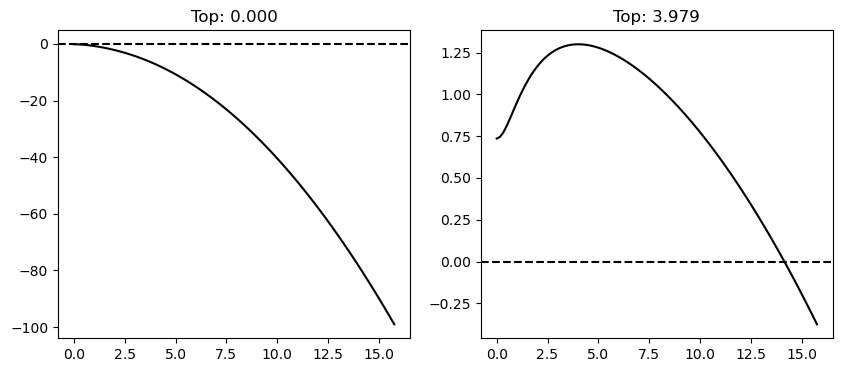

 GPU Monte Carlo Simulation Start (10000000 photons, 39 batches)



Simulating photons:   0%|                      | 0/39 [00:00<?, ?it/s]C:\Users\socce\anaconda3\Lib\site-packages\numba\cuda\cudadrv\devicearray.py:888: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
Simulating photons: 100%|█████████████| 39/39 [05:09<00:00,  7.94s/it]



✅ GPUモンテカルロ計算が完了しました。

✅ Saved 4D CSV: D:/exp_results\case0393\case_0393_results.csv
✅ Saved all to: D:/exp_results\case0393
saved at: D:/exp_results\case0393

===== FULL RUN 394/1211 (same conditions) =====
選ばれた真皮厚み: 2.00 mm
Normal selected
骨状態: normal
緻密骨厚さ: 1.000 mm
BV/TV: 0.185
aBMD:0.714


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.50it/s]


BV/TV = 0.1850
{'BV/TV': 0.18537719241858794, 'BV/TV real': 0.18498272476784916, 'Tb.N* [/mm]': 5.088178868939496, 'Tb.Th [mm]': 0.03635538952788509, 'Tb.Sp [mm]': 0.1601785818119285, 'Dtorb [mg/cm3]': 221.979269721419}
initial value [{p: 0.0, q: 0.0}, {p: -0.387298334620742*I, q: -0.290473750965556*I}, {p: 0.387298334620742*I, q: 0.290473750965556*I}]
fu = 1.600, fv = -1.000, gu = 1.500, gv = -1.000
Solution of λ [-0.0051*k**2 - 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3, -0.0051*k**2 + 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3]


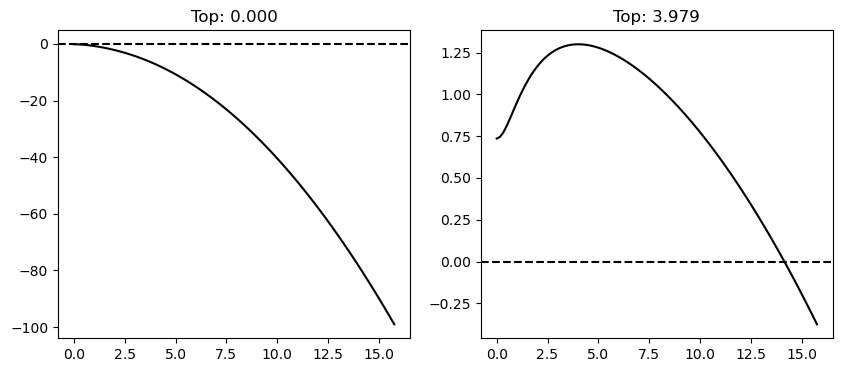

 GPU Monte Carlo Simulation Start (10000000 photons, 39 batches)



Simulating photons: 100%|█████████████| 39/39 [05:08<00:00,  7.92s/it]



✅ GPUモンテカルロ計算が完了しました。

✅ Saved 4D CSV: D:/exp_results\case0394\case_0394_results.csv
✅ Saved all to: D:/exp_results\case0394
saved at: D:/exp_results\case0394

===== FULL RUN 395/1211 (same conditions) =====
選ばれた真皮厚み: 1.00 mm
Osteoporosis selected
骨状態: osteoporosis
緻密骨厚さ: 1.000 mm
BV/TV: 0.052
aBMD:0.461


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.49it/s]


BV/TV = 0.0514
{'BV/TV': 0.05225786181329562, 'BV/TV real': 0.05139685491551149, 'Tb.N* [/mm]': 2.4484003305778104, 'Tb.Th [mm]': 0.020992014366940592, 'Tb.Sp [mm]': 0.3874379255865493, 'Dtorb [mg/cm3]': 61.676225898613794}
initial value [{p: 0.0, q: 0.0}, {p: -0.387298334620742*I, q: -0.290473750965556*I}, {p: 0.387298334620742*I, q: 0.290473750965556*I}]
fu = 1.600, fv = -1.000, gu = 1.500, gv = -1.000
Solution of λ [-0.0051*k**2 - 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3, -0.0051*k**2 + 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3]


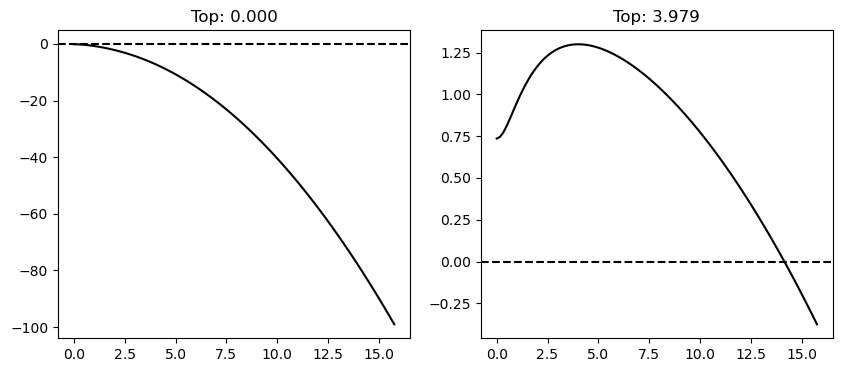

 GPU Monte Carlo Simulation Start (10000000 photons, 39 batches)



Simulating photons: 100%|█████████████| 39/39 [05:45<00:00,  8.86s/it]



✅ GPUモンテカルロ計算が完了しました。

✅ Saved 4D CSV: D:/exp_results\case0395\case_0395_results.csv
✅ Saved all to: D:/exp_results\case0395
saved at: D:/exp_results\case0395

===== FULL RUN 396/1211 (same conditions) =====
選ばれた真皮厚み: 2.00 mm
Osteoporosis selected
骨状態: osteoporosis
緻密骨厚さ: 1.000 mm
BV/TV: 0.105
aBMD:0.560


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.56it/s]


BV/TV = 0.1057
{'BV/TV': 0.1045723119408785, 'BV/TV real': 0.1057307628965043, 'Tb.N* [/mm]': 3.945824330611803, 'Tb.Th [mm]': 0.026795608227219447, 'Tb.Sp [mm]': 0.22663686017791843, 'Dtorb [mg/cm3]': 126.87691547580515}
initial value [{p: 0.0, q: 0.0}, {p: -0.387298334620742*I, q: -0.290473750965556*I}, {p: 0.387298334620742*I, q: 0.290473750965556*I}]
fu = 1.600, fv = -1.000, gu = 1.500, gv = -1.000
Solution of λ [-0.0051*k**2 - 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3, -0.0051*k**2 + 0.435889894354067*sqrt(0.000126368421052632*k**4 + 0.0670526315789474*k**2 + 1) + 0.3]


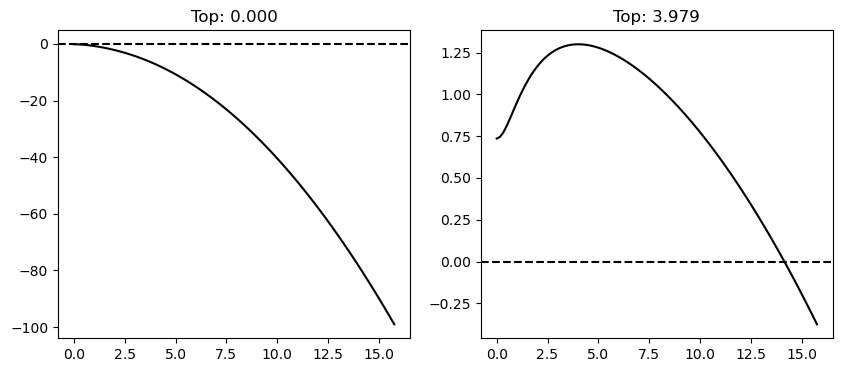

 GPU Monte Carlo Simulation Start (10000000 photons, 39 batches)



Simulating photons:  79%|██████████▎  | 31/39 [04:52<01:15,  9.45s/it]


KeyboardInterrupt: 

In [18]:
if __name__ == "__main__":
    ROOT = r"D:/exp_results"
    START = 392
    REPEAT = 1211  
    for k in range(START, START + REPEAT):
        print(f"\n===== FULL RUN {k+1}/{REPEAT} (same conditions) =====")
        info = run_full_case(root=ROOT,
            N_photons=10000000, max_iter=10000,
            seed_offset=10000 * k,   # ★同条件で乱数だけ変えたい時に有効（関数内のコメント参照）
            case_tag=None, case_name=f"case{k+1:04d}"
        )
        print("saved at:", info["case_dir"])
    print("\n＝＝＝＝＝全ループ完了＝＝＝＝＝")